In [61]:
import numpy as np
import pandas as pd

In [62]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [64]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [67]:
#remove unnecessary columns
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [68]:
#one hot encoding
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [69]:
#X = input data (all columns except target)
#y = output (what we want to predict)
X = df.drop(columns=['Exited'])
y = df['Exited'].values

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [70]:
#fit() → learn mean & standard deviation
#transform() → apply scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#after scaling new_value = (value - mean) / std

X_train_trf = scaler.fit_transform(X_train)

#Only transform, not fit again so that it learns from training data and applies on test data
X_test_trf = scaler.transform(X_test)

In [71]:
X_train_trf

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]], shape=(8000, 11))

In [72]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [73]:
model = Sequential()
#input layer (11 rows) + hidden layer
model.add(Dense(11,activation='sigmoid',input_dim=11))
#hidden layer (11 neurons)
model.add(Dense(11,activation='sigmoid'))
#output layer
model.add(Dense(1,activation='sigmoid'))

c:\Users\VAISHNAVI\anaconda3\envs\notebook\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
#compile model (loss func help to minimize loss)
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [80]:
#model fit
history = model.fit(X_train_trf,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7605 - loss: 0.5633 - val_accuracy: 0.7969 - val_loss: 0.5021
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7958 - loss: 0.4969 - val_accuracy: 0.7969 - val_loss: 0.4907
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7958 - loss: 0.4855 - val_accuracy: 0.7969 - val_loss: 0.4787
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7958 - loss: 0.4710 - val_accuracy: 0.7969 - val_loss: 0.4637
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.4541 - val_accuracy: 0.7969 - val_loss: 0.4487
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.4398 - val_accuracy: 0.7969 - val_loss: 0.4391
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7991 - loss: 0.4312 - val_accuracy: 0.8075 - val_loss: 0.4343
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8091 - loss: 0.4272 - val_accu

In [81]:
#to know all the weights which are stored
model.layers[0].get_weights()

[array([[-0.20356908, -0.06903564,  0.08205541,  0.28865242,  0.00946449,
          0.24285473, -0.2809006 ,  0.37813258, -0.36718452, -0.20580116,
         -0.18819849],
        [ 2.598518  , -0.7123404 , -0.6973639 , -2.1167362 ,  2.420872  ,
         -2.0315514 ,  0.2080568 ,  0.6801816 , -2.0081217 ,  0.5143825 ,
         -2.2666366 ],
        [-0.42057464,  0.4239939 ,  0.16206753, -0.3639498 , -0.52771896,
         -0.49905822, -0.24124663,  0.56884956, -0.02334588, -0.18480332,
         -0.0051505 ],
        [-0.77204156, -0.03177909, -0.0877631 , -0.75105155, -0.3742477 ,
         -0.17831835, -0.03014794, -0.5239373 , -0.60124457, -0.44103804,
         -0.42373592],
        [ 0.07739747, -0.03876708,  0.05790219,  0.25885966,  0.10328274,
          0.55721873, -0.05665914, -0.09009554,  0.14554958,  0.0218547 ,
          0.16866517],
        [-0.2090709 , -0.74618506, -0.38117027, -0.26606175, -0.11281557,
         -0.39006603,  0.01186536,  0.31435087,  0.9017983 , -0.2384045

In [82]:
#make predictions on test data
y_log=model.predict(X_test_trf)
y_log

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([[0.17916061],
       [0.26482806],
       [0.15789394],
       ...,
       [0.12174901],
       [0.1118504 ],
       [0.19839913]], shape=(2000, 1), dtype=float32)

In [83]:
#get output in o and 1 so make threshold if output>0.5 then 1 else 0
y_pred=np.where(y_log>0.5,1,0)
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [84]:
#y test is actual data and y pred is our prediction
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.845

In [85]:
print(y_test.shape)
print(y_pred.shape)

(2000,)
(2000, 1)


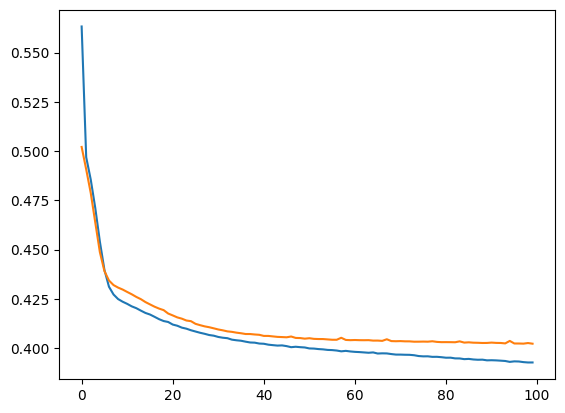

In [88]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

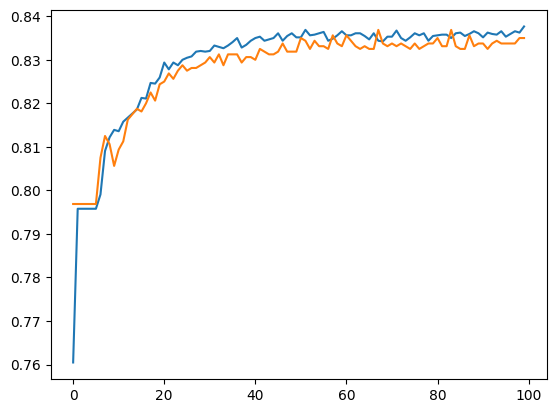

In [90]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])